columns.tsv file was very messy and had many inconsistencies and errors, so instead of trying to analyse it completely, i just simply extracted the relevant information from that file, i.e the ID's of the gene symbols XBP1 and GATA3 and did my further analysis with filtered.tsv which was more clean and usable


In [150]:
import pandas as pd
path1 = "BEE_Data/q6_data/filtered.tsv"
path2 = "BEE_Data/q6_data/columns.tsv"
path3 = "BEE_Data/q6_data/class.tsv"
# i Skipped rows with inconsistent number of columns
name_map = pd.read_csv(path2 , on_bad_lines = 'skip' , sep='\t', comment='#')
print(name_map.columns.tolist())  

cancer_labels = pd.read_csv(path3, header=None)
gene_exp = pd.read_csv(path1, sep='\t')


['ID', 'TYPE', 'ReporterID', 'GeneName', 'GeneSymbol', 'UniGeneCluster', 'UniGeneBuild', 'GB_LIST', 'EntrezGene', 'vector', 'InsertLength', 'ARRAY_BLOCK', 'BLOCK_COLUMN', 'BLOCK_ROW', 'SPOT_ID', 'CLONE_ID']


In [152]:
#print(name_map.head)

In [154]:
#getting the gene ID's
name_map['GeneSymbol'] = name_map['GeneSymbol'].str.strip().str.upper()
filtered_data = name_map[name_map['GeneSymbol'].isin(['XBP1', 'GATA3'])]

gene_ids = filtered_data['ID']
print(gene_ids)

4358    4359
4403    4404
Name: ID, dtype: int64


In [156]:
#print(gene_exp.head(10))

In [178]:
#  the column names were not strictly integer or strings, so the following line to Strip leading and trailing spaces
gene_exp.columns = gene_exp.columns.str.strip()

# Filtering gene_exp to keep only the columns with IDs 4404 and 4358
filtered_gene_exp = gene_exp[['4404', '4359']].copy()
filtered_gene_exp['Cancer'] = cancer_labels.values

print(filtered_gene_exp)

       4404    4359  Cancer
0    2.7836  2.2544       1
1   -0.3359 -0.7640       0
2   -1.0298  2.2355       0
3    2.6186  3.1732       1
4    2.5230  2.7418       1
..      ...     ...     ...
100  2.4375 -0.7596       0
101  2.7557  0.7786       0
102  1.2332  1.8336       0
103  2.5307  1.4419       1
104  1.0580  0.9129       0

[105 rows x 3 columns]


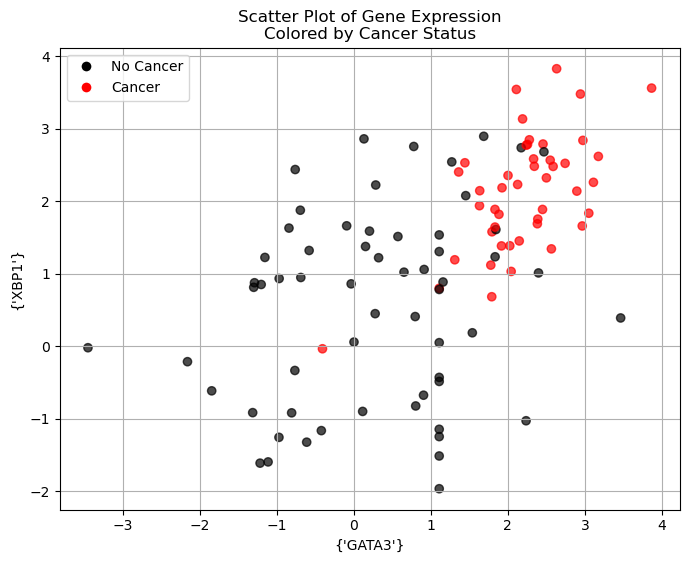

In [182]:
import matplotlib.pyplot as plt


x_gene_symbol = "GATA3"  # for 4359
y_gene_symbol = "XBP1"   # for 4404

# Scatter plot
plt.figure(figsize=(8, 6))
colors = ['black' if c == 0 else 'red' for c in filtered_gene_exp['Cancer']]
plt.scatter(filtered_gene_exp['4359'], filtered_gene_exp['4404'], c=colors, alpha=0.7)

# Labels and title
plt.xlabel({x_gene_symbol} )
plt.ylabel({y_gene_symbol})
plt.title('Scatter Plot of Gene Expression\nColored by Cancer Status')
plt.grid(True)
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='No Cancer', markerfacecolor='black', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Cancer', markerfacecolor='red', markersize=8)
])
plt.show()


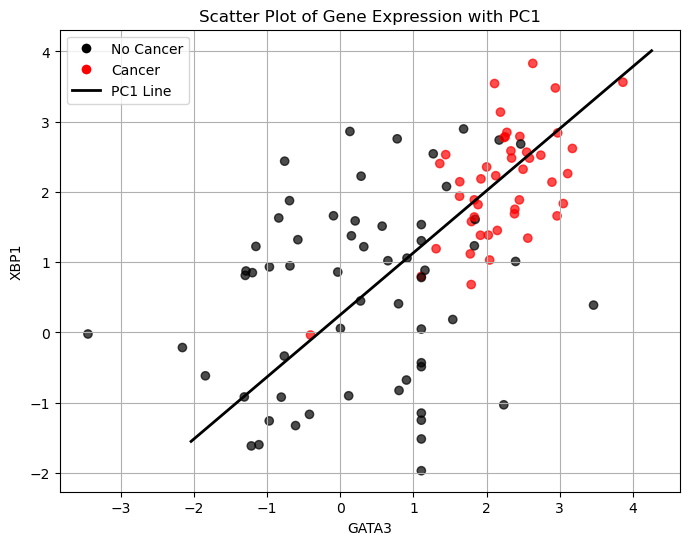

In [194]:
from sklearn.decomposition import PCA
import numpy as np

# Get excluding the 'Cancer' column
X = filtered_gene_exp[['4359', '4404']].values

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

pc1 = pca_result[:, 0]

# Scatter plot
plt.figure(figsize=(8, 6))
colors = ['black' if c == 0 else 'red' for c in filtered_gene_exp['Cancer']]
plt.scatter(filtered_gene_exp['4359'], filtered_gene_exp['4404'], c=colors, alpha=0.7)

# Add PCA line (PC1 direction)
pc1_mean = np.mean(X, axis=0)
pc1_direction = pca.components_[0]  # direction of PC1
pc1_start =  pc1_mean - 3* np.std(X, axis=0) * pc1_direction
pc1_end = pc1_mean +  3* np.std(X, axis=0) * pc1_direction  # Extend the line

plt.plot([pc1_start[0], pc1_end[0]], [pc1_start[1], pc1_end[1]], color='black', label='PC1', linewidth=2)

# Labels and title
plt.xlabel(x_gene_symbol)
plt.ylabel(y_gene_symbol)
plt.title('Scatter Plot of Gene Expression with PC1')
plt.grid(True)
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='No Cancer', markerfacecolor='black', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Cancer', markerfacecolor='red', markersize=8),
    plt.Line2D([0], [0], color='black', lw=2, label='PC1 Line')  # Label for the PC1 line
])
plt.show()


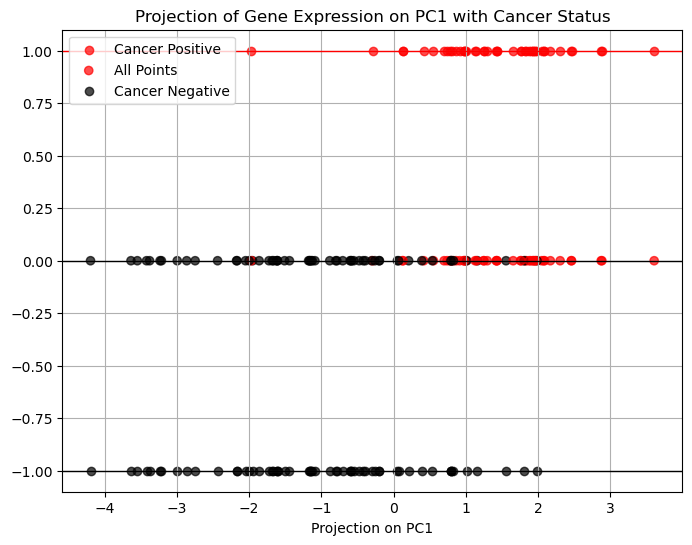

In [200]:
# Project points on PC1
pc1_proj = np.dot(X - np.mean(X, axis=0), pca.components_[0])

# Plotting the three parallel lines (one for each projection)
plt.figure(figsize=(8, 6))

# Plot for cancer-positive points
cancer_positive_proj = pc1_proj[filtered_gene_exp['Cancer'] == 1]
plt.scatter(cancer_positive_proj, np.ones_like(cancer_positive_proj) * 1, color='red', alpha=0.7, label='Cancer Positive')
# Plot for all points
plt.scatter(pc1_proj, np.zeros_like(pc1_proj), c=colors, alpha=0.7, label='All Points', marker='o')

# Plot for cancer-negative points
cancer_negative_proj = pc1_proj[filtered_gene_exp['Cancer'] == 0]
plt.scatter(cancer_negative_proj, np.ones_like(cancer_negative_proj) * -1, color='black', alpha=0.7, label='Cancer Negative')

plt.axhline(0, color='black', lw=1)
plt.axhline(1, color='red', lw=1)
plt.axhline(-1, color='black', lw=1)

plt.xlabel('Projection on PC1')
plt.title('Projection of Gene Expression on PC1 with Cancer Status')
plt.legend()
plt.grid(True)
plt.show()
